# Single 400-track event — eigenvalues, the notch, and the false positives

One fixed-ε ($`\varepsilon=2`$ mrad, $`\gamma=3,\delta=1`$) **400-track** event, solved
classically and with the 1BQF. We dissect, analytically and on the stored solves:

1. **Is there one "bad" eigenvalue?** The activation Hamiltonian is $`A=(\gamma+\delta)I-C`$
   with $`C`$ the 0/1 angle-compatibility adjacency. Any **isolated** segment
   (no compatible neighbour) is an eigenvector with eigenvalue **exactly**
   $`\lambda=\gamma+\delta`$ — and the 1-bit filter $`f(\lambda)=\cos(\lambda t/2)`$,
   $`t=\pi/(\gamma+\delta)`$, has its **single zero** there: $`f(\gamma+\delta)=\cos\frac\pi2=0`$.
   So there is one *bad eigenvalue* (the notch), hugely degenerate.
2. **Is it rotated to zero amplitude?** The post-selected 1BQF amplitude along
   that eigenspace is $`\propto f(\gamma+\delta)=0`$.
3. **Then why do some false segments have $`x_Q>\tau`$?** Because those are
   *not* isolated — they are coupled, off the notch, so $`f\ne0`$ there.
4. **Which tracks?** We trace each false-active segment to the two real tracks
   its endpoints belong to.

In [1]:
import sys
sys.path.insert(0, "/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Segment_level_studies")
from pathlib import Path
import numpy as np, pandas as pd
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt
import seg_store as S, qtrk_pipeline as qp

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})
OUT = Path(S.__file__).resolve().parent / "outputs" / "single_event_400"
OUT.mkdir(parents=True, exist_ok=True)
G, D = 3.0, 1.0
SDIAG = G + D            # gamma+delta = 4  (the notch eigenvalue)
TVAL = np.pi / SDIAG     # HHL evolution time t = pi/(gamma+delta)
TAU = S.threshold(G)     # 0.35
print(f"gamma+delta = {SDIAG}  ->  notch lambda = {SDIAG};  t = pi/{SDIAG};  tau = {TAU}")

gamma+delta = 4.0  ->  notch lambda = 4.0;  t = pi/4.0;  tau = 0.35


In [2]:
# ---- load ONE 400-track event (classical + quantum), regenerate A, truth ----
CI = S.solves_index("classical", gamma=G, hit_ineff=0.0)
QI = S.solves_index("quantum",   gamma=G, hit_ineff=0.0)
q = QI[QI.n_trk == 400].iloc[0]
c = CI[(CI.event_key == q.event_key) & (CI.ham_key == q.ham_key)].iloc[0]
solC = np.asarray(qp.load_solution(c.sol_key)["sol"], float)
solQraw = np.asarray(qp.load_solution(q.sol_key)["sol"], float)
ev = S._event_of(c)
ham = qp.build_hamiltonian(ev, epsilon=float(c.epsilon), gamma=G, delta=D)
A = ham.A.tocsr(); nseg = ham.n_segments
truth = np.asarray(qp.truth_from_event(ev), bool)
solQ = qp.rescale_to_signal(solQraw, solC, TAU)            # corrected (signal-support) rescale
tid = np.asarray(ham._segment_track_ids)                    # (nseg,2) [start_tid,end_tid]
xyz = np.asarray(ham._segment_endpoints_xyz)                # (nseg,2,3)
print(f"event_key={c.event_key[:16]}  n_seg={nseg}  n_true={int(truth.sum())}  (= 4*T = {4*400})")

# compatibility graph C = (gamma+delta) I - A, off-diagonal support
Cmat = (SDIAG * sp.identity(nseg, format="csr") - A); Cmat.setdiag(0); Cmat.eliminate_zeros()
Cmat = (abs(Cmat) > 1e-9).astype(np.int8)
deg = np.asarray(Cmat.sum(1)).ravel()
ncomp, lab = connected_components(Cmat, directed=False)
csize = np.bincount(lab)
iso = deg == 0
print(f"isolated (degree 0): {iso.sum()} ({iso.mean()*100:.2f}%)  ->  eigenvalue exactly gamma+delta={SDIAG}")
print(f"coupled (degree>=1): {(~iso).sum()}  in {ncomp - iso.sum()} non-trivial components")

event_key=ev_591b8b9b4b66  n_seg=640000  n_true=1600  (= 4*T = 1600)
isolated (degree 0): 637111 (99.55%)  ->  eigenvalue exactly gamma+delta=4.0
coupled (degree>=1): 2889  in 1033 non-trivial components


## 1. The spectrum is a giant delta at the notch plus a few satellites
$`A=(\gamma+\delta)I-C`$ is **block-diagonal over the connected components** of
the compatibility graph. A degree-0 (isolated) segment is a $`1\times1`$ block
$`[\gamma+\delta]`$ — eigenvalue exactly $`\gamma+\delta`$. So the full spectrum is
$`\{\gamma+\delta\}`$ with multiplicity = #isolated, plus the eigenvalues of the
small coupled blocks. We can therefore get the *entire* $`640{,}000`$-dim spectrum
without a dense diagonalisation: diagonalise only the (few thousand) coupled rows.

coupled submatrix: 2889 x 2889; lambda range [1.201, 6.799]
eigenvalues exactly at the notch (|lambda-4|<1e-6): 637128 of 640000  (99.55%)


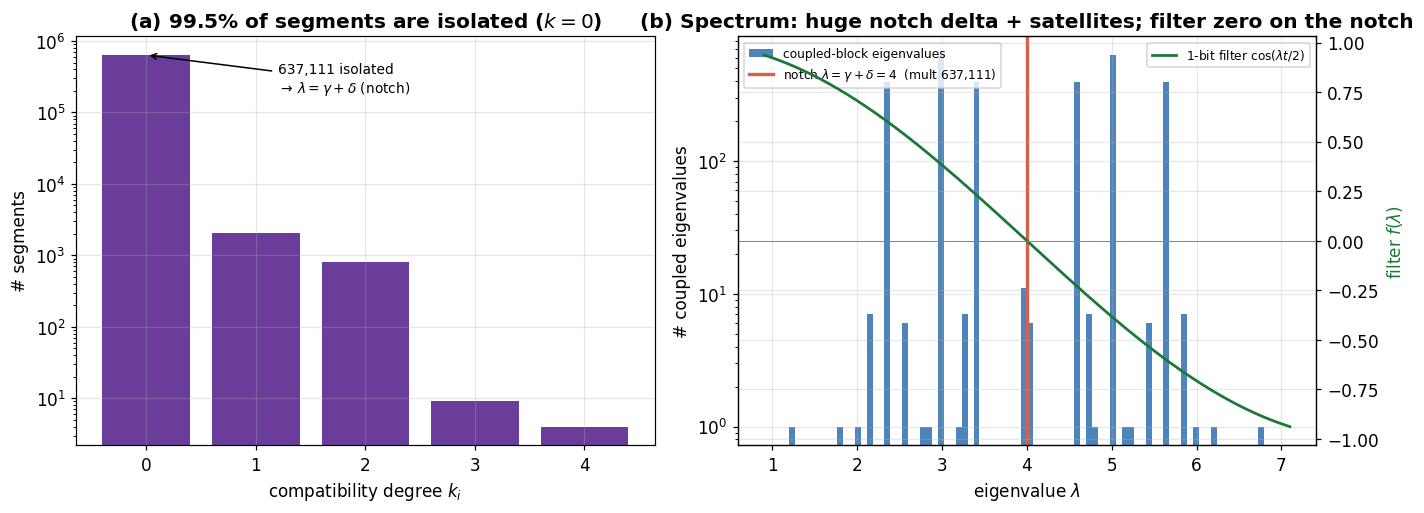

saved spectrum_notch


In [3]:
# full spectrum = [gamma+delta]*n_isolated  +  eig(coupled submatrix)
cidx = np.where(~iso)[0]
Asub = A[cidx][:, cidx].toarray()
lam_coupled = np.linalg.eigvalsh(Asub)
lam_all = np.concatenate([np.full(int(iso.sum()), SDIAG), lam_coupled])
print(f"coupled submatrix: {Asub.shape[0]} x {Asub.shape[0]}; "
      f"lambda range [{lam_coupled.min():.3f}, {lam_coupled.max():.3f}]")
print(f"eigenvalues exactly at the notch (|lambda-{SDIAG:.0f}|<1e-6): "
      f"{int((np.abs(lam_all-SDIAG)<1e-6).sum())} of {nseg}  "
      f"({(np.abs(lam_all-SDIAG)<1e-6).mean()*100:.2f}%)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
# (a) degree distribution
dvals, dcounts = np.unique(deg, return_counts=True)
ax[0].bar(dvals, dcounts, color="#6a3d9a", width=0.8)
ax[0].set_yscale("log"); ax[0].set_xlabel("compatibility degree $k_i$"); ax[0].set_ylabel("# segments")
ax[0].set_title("(a) 99.5% of segments are isolated ($k=0$)", fontweight="bold")
ax[0].annotate(f"{int(iso.sum()):,} isolated\n$\\to\\,\\lambda=\\gamma+\\delta$ (notch)",
               xy=(0, dcounts[0]), xytext=(1.2, dcounts[0]*0.3), fontsize=9,
               arrowprops=dict(arrowstyle="->"))
# (b) spectrum with the notch + filter
lo, hi = lam_coupled.min()-0.3, lam_coupled.max()+0.3
ax[1].hist(lam_coupled, bins=80, color="#2166ac", alpha=0.8, label="coupled-block eigenvalues")
ax[1].axvline(SDIAG, color="#d6604d", lw=2.2, label=f"notch $\\lambda=\\gamma+\\delta={SDIAG:.0f}$  (mult {int(iso.sum()):,})")
axf = ax[1].twinx()
lg = np.linspace(lo, hi, 400)
axf.plot(lg, np.cos(lg*TVAL/2), color="#1b7837", lw=1.8, label="1-bit filter $\\cos(\\lambda t/2)$")
axf.axhline(0, color="grey", lw=0.6); axf.set_ylabel("filter $f(\\lambda)$", color="#1b7837")
ax[1].set_yscale("log"); ax[1].set_xlabel("eigenvalue $\\lambda$"); ax[1].set_ylabel("# coupled eigenvalues")
ax[1].set_title("(b) Spectrum: huge notch delta + satellites; filter zero on the notch", fontweight="bold")
ax[1].legend(loc="upper left", fontsize=8); axf.legend(loc="upper right", fontsize=8)
fig.tight_layout()
for e, dp in (("pdf", 600), ("png", 300)):
    fig.savefig(OUT / f"spectrum_notch.{e}", dpi=dp, bbox_inches="tight", facecolor="white")
plt.show(); print("saved spectrum_notch")

## 2. The notch eigenspace is rotated to zero amplitude
Classically every isolated segment sits at the Hopfield attractor
$`x_{\rm false}=\delta/(\delta+\gamma)=0.25`$. The 1BQF instead multiplies that
eigenspace by $`f(\gamma+\delta)=0`$ — so its amplitude is annihilated. The stored
solves confirm it to machine precision.

isolated segments  (637,111):
   classical amplitude: median = 0.2500   (delta/(delta+gamma) = 0.2500)
   quantum   amplitude: median = 4.49e-14,  max = 5.96e-13   -> rotated to 0
coupled segments   (2,889):
   classical median = 0.3636;  quantum median = 0.2973


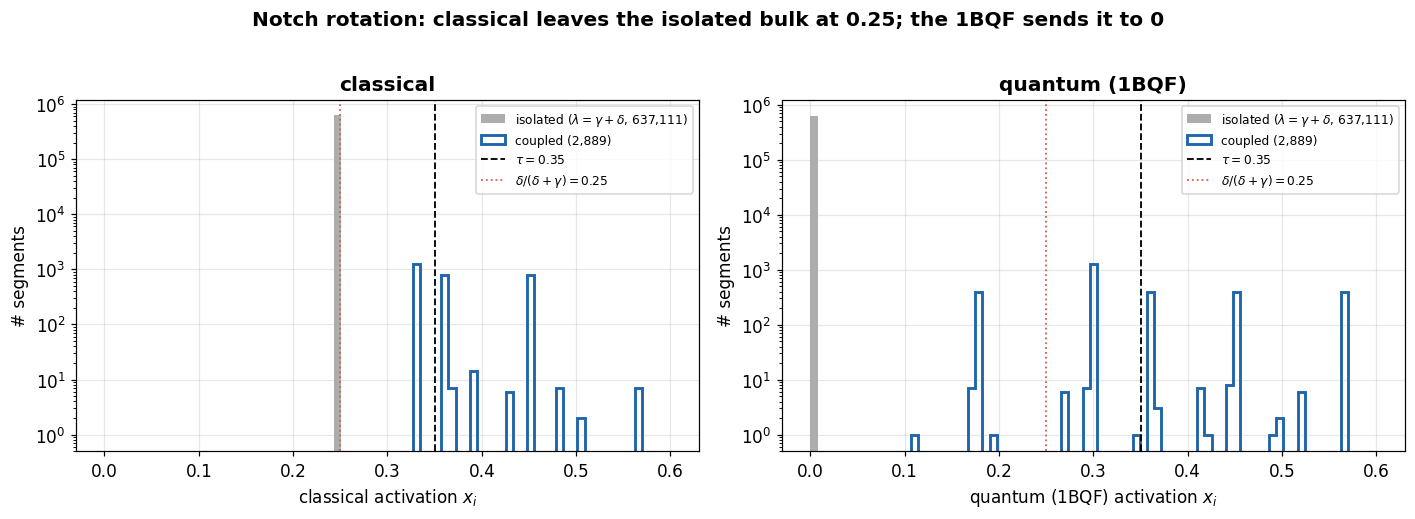

saved notch_rotation


In [4]:
print(f"isolated segments  ({iso.sum():,}):")
print(f"   classical amplitude: median = {np.median(solC[iso]):.4f}   (delta/(delta+gamma) = {D/(D+G):.4f})")
print(f"   quantum   amplitude: median = {np.median(solQ[iso]):.2e},  max = {solQ[iso].max():.2e}   -> rotated to 0")
print(f"coupled segments   ({(~iso).sum():,}):")
print(f"   classical median = {np.median(solC[~iso]):.4f};  quantum median = {np.median(solQ[~iso]):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
bins = np.linspace(0, 0.6, 80)
for a, sol, name in [(ax[0], solC, "classical"), (ax[1], solQ, "quantum (1BQF)")]:
    a.hist(sol[iso], bins=bins, color="#999999", alpha=0.8, label=f"isolated ($\\lambda=\\gamma+\\delta$, {iso.sum():,})")
    a.hist(sol[~iso], bins=bins, histtype="step", color="#2166ac", lw=1.9, label=f"coupled ({(~iso).sum():,})")
    a.axvline(TAU, color="k", ls="--", lw=1.2, label=f"$\\tau={TAU}$")
    a.axvline(D/(D+G), color="#d6604d", ls=":", lw=1.2, label="$\\delta/(\\delta+\\gamma)=0.25$")
    a.set_yscale("log"); a.set_ylim(0.5, None)
    a.set_xlabel(f"{name} activation $x_i$"); a.set_ylabel("# segments"); a.legend(fontsize=8)
    a.set_title(name, fontweight="bold")
fig.suptitle("Notch rotation: classical leaves the isolated bulk at 0.25; the 1BQF sends it to 0",
             fontweight="bold", y=1.02)
fig.tight_layout()
for e, dp in (("pdf", 600), ("png", 300)):
    fig.savefig(OUT / f"notch_rotation.{e}", dpi=dp, bbox_inches="tight", facecolor="white")
plt.show(); print("saved notch_rotation")

## 3. The false positives are cross-track "bridge" clusters
The surviving false-active segments ($`x_Q>\tau`$, truth-false) are all
**coupled** (degree $`\ge1`$) and all connect **two different real tracks** — a hit
of track $`a`$ and a hit of track $`b`$ that happen to be angle-compatible
($`\theta<\varepsilon`$) and share a middle hit, so they ride a coupled cluster off
the notch.

false-active segments: 21
  all coupled (degree>=1): True
  all connect two DIFFERENT real tracks: True
  component sizes hosting them: [np.int64(3), np.int64(5), np.int64(16)]


,seg,track_start,track_end,degree,comp_size,x_classical,x_quantum
3,39869,99,269,2,16,0.727,0.644
14,267699,269,99,3,16,0.869,0.447
17,359869,99,269,2,16,0.678,0.449
10,199869,99,269,3,16,0.869,0.501
6,107699,269,99,2,16,0.727,0.367
20,519869,99,269,1,16,0.505,0.420
4,57466,143,266,1,5,0.392,0.417
1,5496,13,296,1,5,0.392,0.417
2,31847,79,247,1,5,0.392,0.417
0,5316,13,116,1,3,0.357,0.361


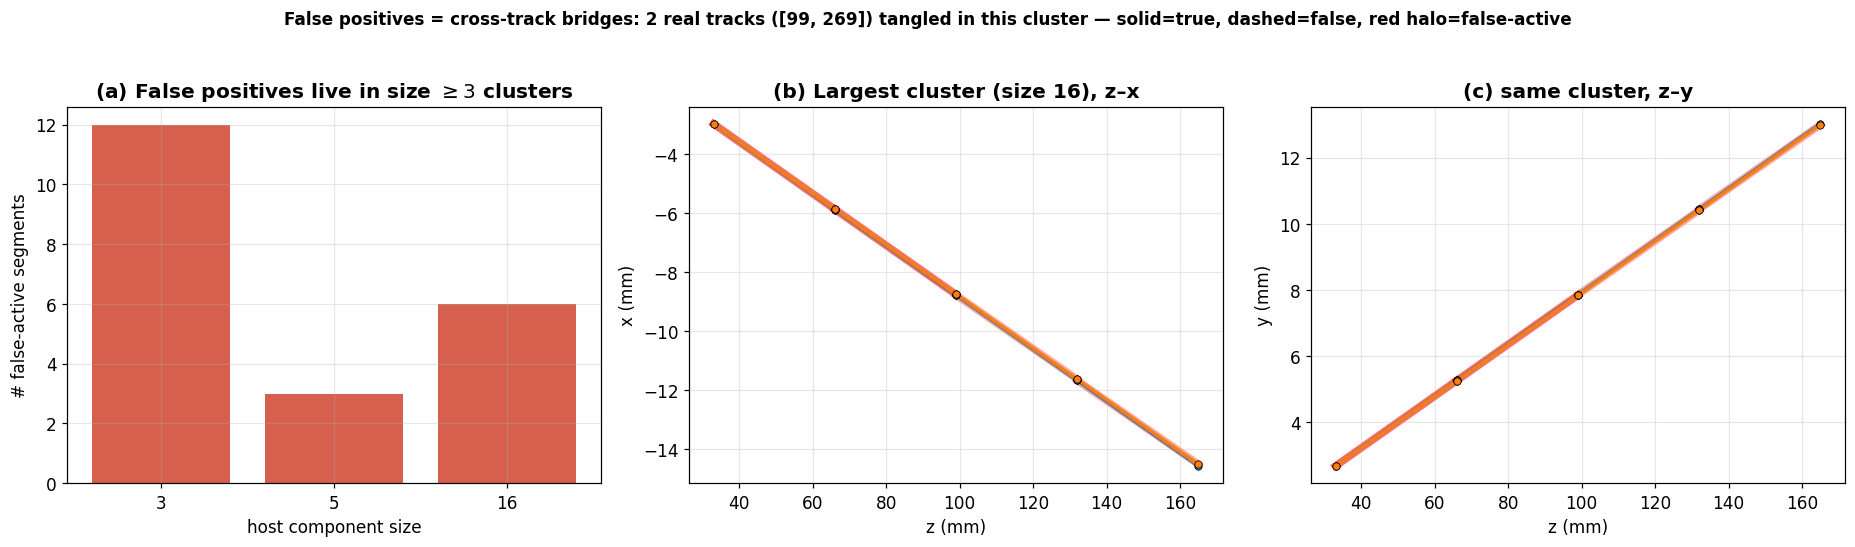

saved false_positive_bridges (largest cluster size 16, tracks [99, 269])


In [5]:
fa = (~truth) & (solQ > TAU)
fa_idx = np.where(fa)[0]
rows = []
for i in fa_idx:
    a_, b_ = int(tid[i, 0]), int(tid[i, 1])
    rows.append(dict(seg=int(i), track_start=a_, track_end=b_, degree=int(deg[i]),
                     comp_size=int(csize[lab[i]]), x_classical=round(float(solC[i]), 3),
                     x_quantum=round(float(solQ[i]), 3)))
fadf = pd.DataFrame(rows).sort_values("comp_size", ascending=False)
print(f"false-active segments: {len(fadf)}")
print(f"  all coupled (degree>=1): {bool((fadf.degree>=1).all())}")
print(f"  all connect two DIFFERENT real tracks: "
      f"{bool(((fadf.track_start!=fadf.track_end)&(fadf.track_start>=0)&(fadf.track_end>=0)).all())}")
print(f"  component sizes hosting them: {sorted(fadf.comp_size.unique())}")
display(fadf.head(21))

import matplotlib.cm as cm
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
vc = fadf.comp_size.value_counts().sort_index()
ax[0].bar(vc.index.astype(str), vc.values, color="#d6604d")
ax[0].set_xlabel("host component size"); ax[0].set_ylabel("# false-active segments")
ax[0].set_title("(a) False positives live in size $\\geq 3$ clusters", fontweight="bold")
# spatial views of the largest offending cluster, in (z,x) and (z,y)
big = int(fadf.iloc[0].comp_size)
comp_id = lab[int(fadf.iloc[0].seg)]
members = np.where(lab == comp_id)[0]
tracks_here = sorted(set(int(t) for m in members for t in tid[m] if t >= 0))
cmap = {tk: cm.tab10(k % 10) for k, tk in enumerate(tracks_here)}
def draw(a, ci):                                  # ci: 0->x, 1->y vs z(=2)
    for m in members:
        p0, p1 = xyz[m, 0], xyz[m, 1]
        is_true = (tid[m, 0] == tid[m, 1]) and tid[m, 0] >= 0
        if m in fa_idx:
            a.plot([p0[2], p1[2]], [p0[ci], p1[ci]], color="red", lw=5, alpha=0.35, zorder=0)
        col = cmap.get(int(tid[m, 0]), "0.4")
        a.plot([p0[2], p1[2]], [p0[ci], p1[ci]], color=col,
               lw=2.4 if is_true else 1.3, ls="-" if is_true else "--", alpha=0.9, zorder=3)
    # hit endpoints coloured by their own track
    for m in members:
        for e2 in (0, 1):
            a.scatter(xyz[m, e2, 2], xyz[m, e2, ci], s=22,
                      color=cmap.get(int(tid[m, e2]), "0.4"), ec="k", lw=0.4, zorder=4)
    a.set_xlabel("z (mm)")
draw(ax[1], 0); ax[1].set_ylabel("x (mm)"); ax[1].set_title(f"(b) Largest cluster (size {big}), z–x", fontweight="bold")
draw(ax[2], 1); ax[2].set_ylabel("y (mm)"); ax[2].set_title(f"(c) same cluster, z–y", fontweight="bold")
fig.suptitle(f"False positives = cross-track bridges: {len(tracks_here)} real tracks "
             f"({tracks_here}) tangled in this cluster — solid=true, dashed=false, red halo=false-active",
             fontsize=11, fontweight="bold", y=1.03)
fig.tight_layout()
for e, dp in (("pdf", 600), ("png", 300)):
    fig.savefig(OUT / f"false_positive_bridges.{e}", dpi=dp, bbox_inches="tight", facecolor="white")
plt.show(); print(f"saved false_positive_bridges (largest cluster size {big}, tracks {tracks_here})")

## 4. Analytic ladder: activation vs cluster size, and where $`\tau`$ sits
$`A`$ decouples over components. For an isolated chain of $`m`$ segments,
$`A_m=(\gamma+\delta)I-P_m`$, solving $`A_m\mathbf{x}=\delta\mathbf{1}`$ gives the
outermost activation $`x^{(m)}_{\rm outer}`$. With $`s=\gamma+\delta=4`$:

| cluster size $`m`$ | structure | $`x_{\rm outer}`$ (exact) | active at $`\tau=0.35`$? |
|---|---|---|---|
| 1 | isolated / false | $`\delta/s=\tfrac14=0.250`$ | no |
| 2 | one coupling | $`\delta/(s-1)=\tfrac13=0.333`$ | no |
| 3 | triple | $`\tfrac{5}{14}=0.357`$ | **yes** |
| 4 | true track chain | $`\tfrac{4}{11}=0.364`$ (inner $`\tfrac{5}{11}`$) | **yes** |

So $`\tau=0.35`$ sits in the window $`(\tfrac13,\tfrac{5}{14})=(0.333,0.357)`$ — it is
designed to reject isolated segments and lone pairs but accept chains of length
$`\ge3`$. A real track is a length-4 chain (accepted); a **false positive is an
accidental cross-track cluster of size $`\ge3`$** that reaches the same activation
band. The eigenvalues of these clusters lie off the notch (e.g. the triple has
$`\lambda\in\{s-\sqrt2,\,s,\,s+\sqrt2\}=\{2.59,4,5.41\}`$), so the 1-bit filter
passes them — which is exactly why they survive into $`x_Q>\tau`$.

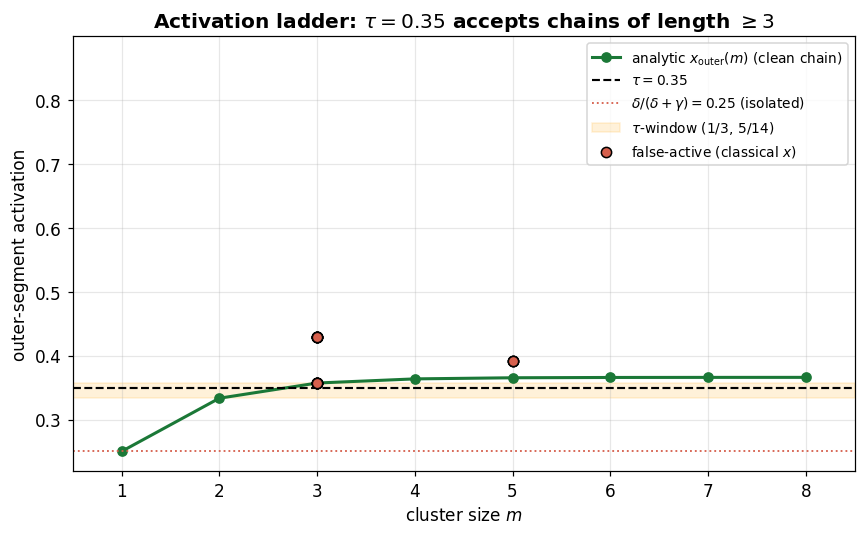

outer activation x_outer(m) for m=1..8: [0.25   0.3333 0.3571 0.3636 0.3654 0.3659 0.366  0.366 ]
saved activation_ladder


In [6]:
# analytic outer activation vs chain length m, with the empirical false-active band
def outer_chain(m, s=SDIAG, dlt=D):
    Am = s*np.eye(m) - (np.eye(m, k=1) + np.eye(m, k=-1))
    return np.linalg.solve(Am, dlt*np.ones(m))[0]
ms = np.arange(1, 9)
xo = np.array([outer_chain(m) for m in ms])
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ms, xo, "o-", color="#1b7837", lw=2, label="analytic $x_{\\rm outer}(m)$ (clean chain)")
ax.axhline(TAU, color="k", ls="--", lw=1.4, label=f"$\\tau={TAU}$")
ax.axhline(D/(D+G), color="#d6604d", ls=":", lw=1.2, label="$\\delta/(\\delta+\\gamma)=0.25$ (isolated)")
ax.fill_between([0.5, 8.5], 1/3, 5/14, color="orange", alpha=0.15,
                label="$\\tau$-window $(1/3,\\,5/14)$")
# overlay the actual false-active classical activations vs their cluster size
ax.scatter(fadf.comp_size, fadf.x_classical, s=45, color="#d6604d", ec="k", zorder=5,
           label="false-active (classical $x$)")
ax.set_xlabel("cluster size $m$"); ax.set_ylabel("outer-segment activation")
ax.set_title("Activation ladder: $\\tau=0.35$ accepts chains of length $\\geq 3$", fontweight="bold")
ax.set_xlim(0.5, 8.5); ax.legend(fontsize=9)
fig.tight_layout()
for e, dp in (("pdf", 600), ("png", 300)):
    fig.savefig(OUT / f"activation_ladder.{e}", dpi=dp, bbox_inches="tight", facecolor="white")
plt.show()
print("outer activation x_outer(m) for m=1..8:", np.round(xo, 4))
print("saved activation_ladder")

## 5. Answers

- **One bad eigenvalue?** Yes — a single bad *value* $`\lambda=\gamma+\delta`$ (the
  filter's only in-band zero), but with multiplicity = #isolated segments
  ($`\approx99.5\%`$ of all $`640{,}000`$). Every decoupled segment is exactly there.
- **Rotated to zero?** Yes — $`f(\gamma+\delta)=\cos\frac\pi2=0`$ sends that whole
  eigenspace to zero amplitude (stored quantum median $`\sim10^{-14}`$ on isolated
  segments, vs the classical $`0.25`$). The 1BQF is in fact a **perfect false-segment
  filter for the isolated bulk** — better than classical there.
- **Why do some false segments survive with $`x_Q>\tau`$?** They are not isolated:
  they sit in coupled clusters whose eigenvalues are *off* the notch, so $`f\ne0`$.
  Only clusters of size $`\ge3`$ reach the $`\tau`$ band.
- **Which tracks?** Every false-active segment connects **two different real
  tracks** — accidental angle-compatible cross-track pairings that share a middle
  hit. They are geometric "bridges" between distinct trajectories in locally dense
  regions (the largest tangle here mixes several tracks), *not* a solver defect:
  the classical solver promotes the very same clusters.